In [ ]:
import numpy as np
import pandas as pd




In [ ]:
df=pd.read_csv('/content/PlayTennis.csv')
df.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [ ]:
from matplotlib import pyplot as plt
from sklearn import datasets,tree
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [ ]:
input = df.drop('Play Tennis', axis=1)
target = df['Play Tennis']

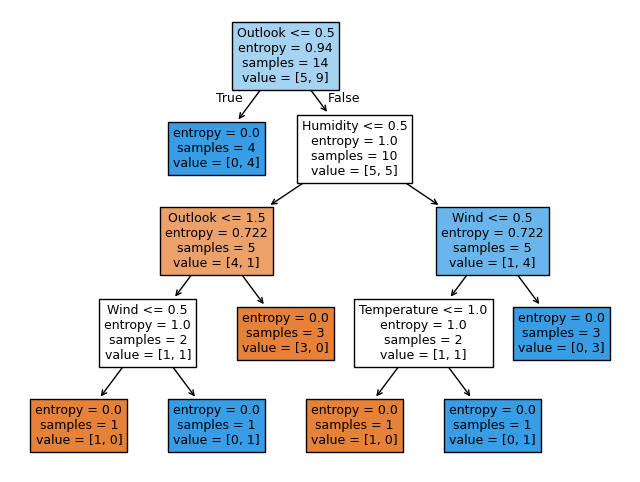

In [ ]:
from os import CLONE_FILES
outlook = LabelEncoder()
temp = LabelEncoder()
humidity = LabelEncoder()
wind = LabelEncoder()
play = LabelEncoder()
# input = input.drop('day', axis=1) # Removed as 'day' column does not exist

input['Outlook'] = outlook.fit_transform(input['Outlook'])
input['Temperature'] = temp.fit_transform(input['Temperature'])
input['Humidity'] = humidity.fit_transform(input['Humidity'])
input['Wind'] = wind.fit_transform(input['Wind'])

output = play.fit_transform(target)

clf = DecisionTreeClassifier(criterion='entropy')
model = clf.fit(input, output)

fig = plt.figure(figsize=(8,6))
_=tree.plot_tree(model, feature_names=input.columns,filled=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(input, output, test_size=0.2, random_state=42)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1 0]
 [0 2]]


In [ ]:
import numpy as np
from math import log2

def entropy(labels):
    unique_labels, counts = np.unique(labels, return_counts=True)
    total = len(labels)
    ent = 0

    for count in counts:
        p = count / total
        ent -= p * log2(p)

    return ent